# MA402 Final Project
## Rosenbrock Function Minimization with PETSc TAO

**Domain:** Data Science & Optimization  
**Solver:** PETSc TAO — L-BFGS quasi-Newton (`lmvm`)  
**NC State University · Spring 2026**

---

## 1. Mathematical Formulation

We solve the **unconstrained minimization** problem:

$$\min_{\mathbf{x} \in \mathbb{R}^n} f(\mathbf{x}) = \sum_{i=0}^{n-2} \left[ 100\,(x_{i+1} - x_i^2)^2 + (1 - x_i)^2 \right]$$

### Properties

| Property | Value |
|---|---|
| Domain | $\mathbb{R}^n$, unconstrained |
| Global minimum | $\mathbf{x}^* = (1, 1, \ldots, 1)$ |
| Minimum value | $f(\mathbf{x}^*) = 0$ |
| Smoothness | $C^\infty$ |
| Convexity | Non-convex |
| Difficulty | Narrow parabolic valley; ill-conditioned Hessian near $\mathbf{x}^*$ |

### Gradient

$$\frac{\partial f}{\partial x_i} =
\begin{cases}
-400\,x_0(x_1 - x_0^2) - 2(1-x_0) & i=0 \\
200(x_i - x_{i-1}^2) - 400\,x_i(x_{i+1} - x_i^2) - 2(1-x_i) & 0 < i < n-1 \\
200(x_{n-1} - x_{n-2}^2) & i=n-1
\end{cases}$$

### Why L-BFGS?

The **Hessian** $\nabla^2 f$ at $\mathbf{x}^*$ has condition number $\kappa \approx 2508$ for $n=2$, growing with $n$. Pure gradient descent converges extremely slowly. L-BFGS builds an implicit inverse-Hessian approximation using the last $m$ gradient differences:

$$H_k^{-1} \approx \text{two-loop recursion on } \{s_j, y_j\}_{j=k-m}^{k-1}$$

This gives **superlinear convergence** without ever forming $\nabla^2 f$ explicitly.

## 2. Setup

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Import our solver module
# Make sure tutorial_module.py is in the same directory
from tutorial_module import RosenbrockSolver

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print("Setup complete.")

Setup complete.


## 3. Visualizing the Problem Landscape (n = 2)

Before running the solver, let's visualize why the Rosenbrock function is difficult. The minimum lies at the bottom of a narrow, curved valley.

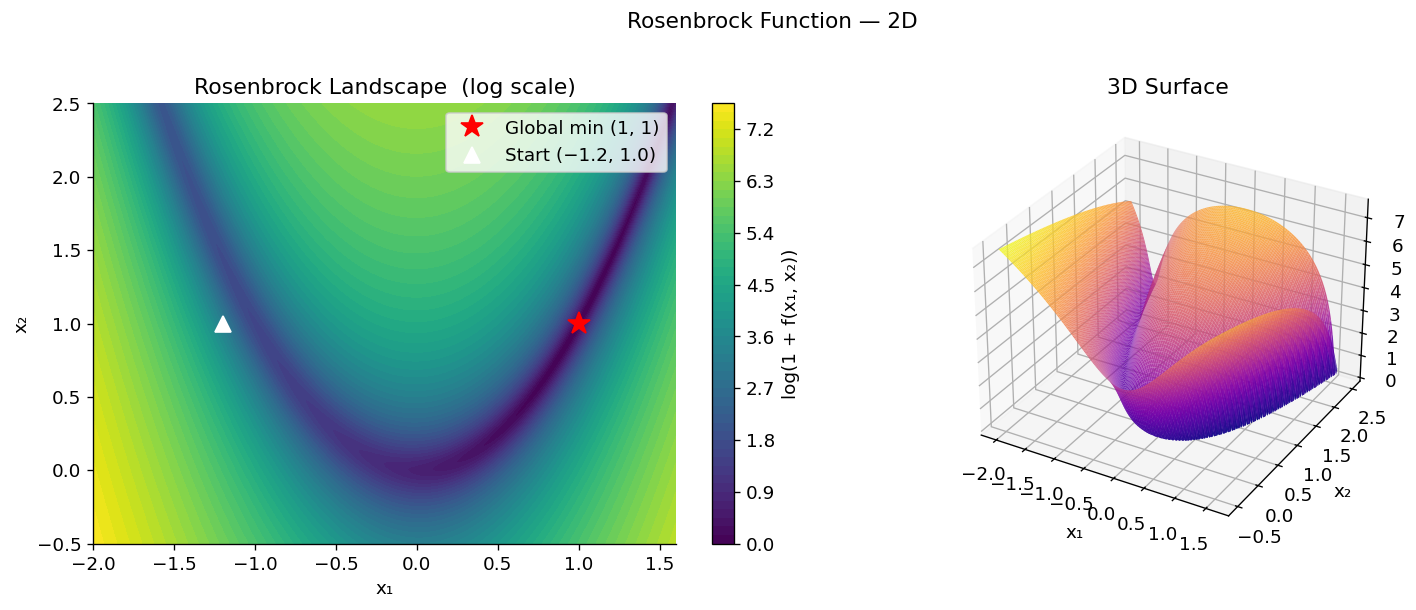

In [2]:
# Build the 2D landscape
x1 = np.linspace(-2.0, 1.6, 600)
x2 = np.linspace(-0.5, 2.5, 600)
X1, X2 = np.meshgrid(x1, x2)
Z = 100.0 * (X2 - X1**2)**2 + (1.0 - X1)**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: filled contour (log scale for visibility)
cs = axes[0].contourf(X1, X2, np.log1p(Z), levels=60, cmap='viridis')
fig.colorbar(cs, ax=axes[0], label='log(1 + f(x₁, x₂))')
axes[0].plot(1, 1, 'r*', markersize=14, label='Global min (1, 1)', zorder=5)
axes[0].plot(-1.2, 1.0, 'w^', markersize=10, label='Start (−1.2, 1.0)', zorder=5)
axes[0].set_xlabel('x₁'); axes[0].set_ylabel('x₂')
axes[0].set_title('Rosenbrock Landscape  (log scale)')
axes[0].legend(framealpha=0.8)

# Right: surface plot
from mpl_toolkits.mplot3d import Axes3D
ax3d = fig.add_subplot(122, projection='3d')
fig.delaxes(axes[1])
ax3d.plot_surface(X1, X2, np.log1p(Z), cmap='plasma', alpha=0.85,
                  rstride=6, cstride=6)
ax3d.set_xlabel('x₁'); ax3d.set_ylabel('x₂')
ax3d.set_zlabel('log(1 + f)')
ax3d.set_title('3D Surface')

plt.suptitle('Rosenbrock Function — 2D', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 4. Running the TAO Solver (n = 2)

We instantiate `RosenbrockSolver`, call `solve()`, and inspect the result.  
The three documented functions — `setObjective`, `setGradient`, and `getConvergedReason` — are all called inside `solve()`.

In [3]:
print("=" * 50)
print("  Rosenbrock — n = 2, TAO L-BFGS")
print("=" * 50)

solver2 = RosenbrockSolver(n=2)
x_opt2, fval2 = solver2.solve()

print(f"\nOptimal x    : {x_opt2}")
print(f"Optimal f(x) : {fval2:.4e}")
print(f"Error ||x*-1||₂ : {np.linalg.norm(x_opt2 - 1.0):.4e}")

  Rosenbrock — n = 2, TAO L-BFGS
  TAO type          : lmvm
  Converged reason  : 3
  Iterations        : 34
  Final f(x)        : 1.574562e-20

Optimal x    : [1. 1.]
Optimal f(x) : 1.5746e-20
Error ||x*-1||₂ : 7.2934e-11


## 5. Convergence History

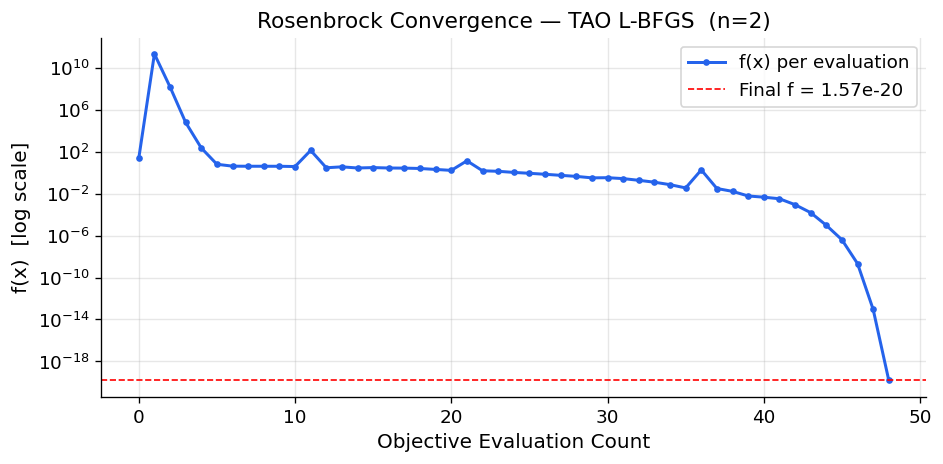

Total objective evaluations: 49
Reduction ratio  f₀/f*     : 1.54e+21


In [4]:
fig, ax = plt.subplots(figsize=(8, 4))

history = np.array(solver2.obj_history)
ax.semilogy(history, marker='o', markersize=3, linewidth=1.8,
            color='#2563EB', label='f(x) per evaluation')

# Mark final value
ax.axhline(fval2, color='red', linestyle='--', linewidth=1,
           label=f'Final f = {fval2:.2e}')

ax.set_xlabel('Objective Evaluation Count', fontsize=12)
ax.set_ylabel('f(x)  [log scale]', fontsize=12)
ax.set_title('Rosenbrock Convergence — TAO L-BFGS  (n=2)', fontsize=13)
ax.legend()
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total objective evaluations: {len(history)}")
print(f"Reduction ratio  f₀/f*     : {history[0] / (fval2 + 1e-300):.2e}")

## 6. Solution Overlaid on Landscape

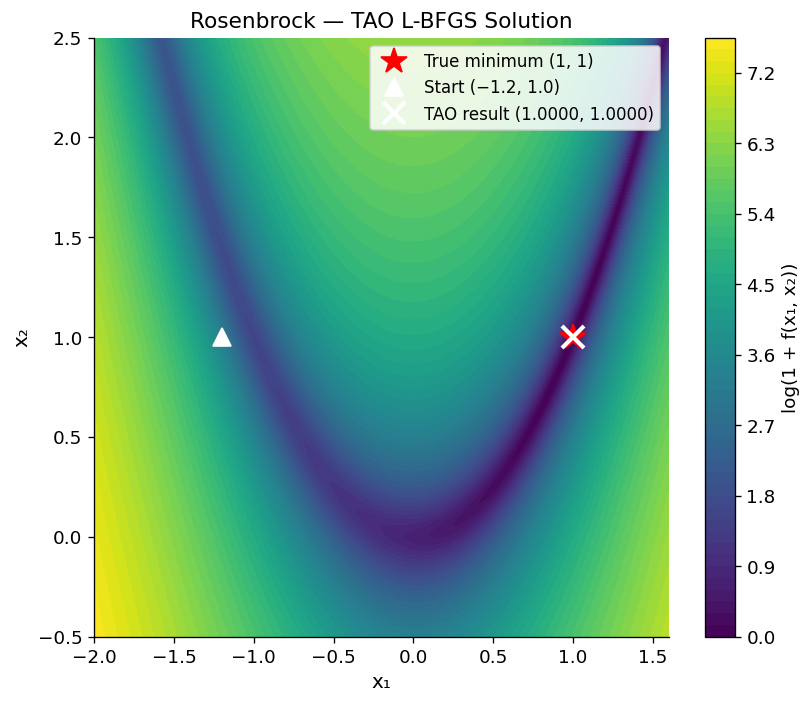

In [5]:
fig, ax = plt.subplots(figsize=(7, 6))

cs = ax.contourf(X1, X2, np.log1p(Z), levels=60, cmap='viridis')
fig.colorbar(cs, ax=ax, label='log(1 + f(x₁, x₂))')

# Mark key points
ax.plot(1.0, 1.0, 'r*', markersize=16, label='True minimum (1, 1)', zorder=5)
ax.plot(-1.2, 1.0, 'w^', markersize=11,
        label='Start (−1.2, 1.0)', zorder=5)
ax.plot(x_opt2[0], x_opt2[1], 'wx', markersize=13, markeredgewidth=2.5,
        label=f'TAO result ({x_opt2[0]:.4f}, {x_opt2[1]:.4f})', zorder=6)

ax.set_xlabel('x₁', fontsize=12)
ax.set_ylabel('x₂', fontsize=12)
ax.set_title('Rosenbrock — TAO L-BFGS Solution', fontsize=13)
ax.legend(framealpha=0.85, fontsize=10)
plt.tight_layout()
plt.show()

## 7. Scalability Study — n = 2, 10, 50, 100

One strength of TAO + L-BFGS is its scalability to high-dimensional problems.  
We compare solver performance across several problem sizes.

  TAO type          : lmvm
  Converged reason  : 3
  Iterations        : 34
  Final f(x)        : 1.574562e-20
n=   2  f*=1.575e-20  ||x*-1||=7.293e-11  evals=49
  TAO type          : lmvm
  Converged reason  : 3
  Iterations        : 137
  Final f(x)        : 3.448307e-19
n=  10  f*=3.448e-19  ||x*-1||=1.031e-09  evals=216
  TAO type          : lmvm
  Converged reason  : -2
  Iterations        : 2000
  Final f(x)        : 1.257890e-12
n=  50  f*=1.258e-12  ||x*-1||=2.241e-06  evals=3826
  TAO type          : lmvm
  Converged reason  : -2
  Iterations        : 2000
  Final f(x)        : 6.255435e-13
n= 100  f*=6.255e-13  ||x*-1||=1.582e-06  evals=3698


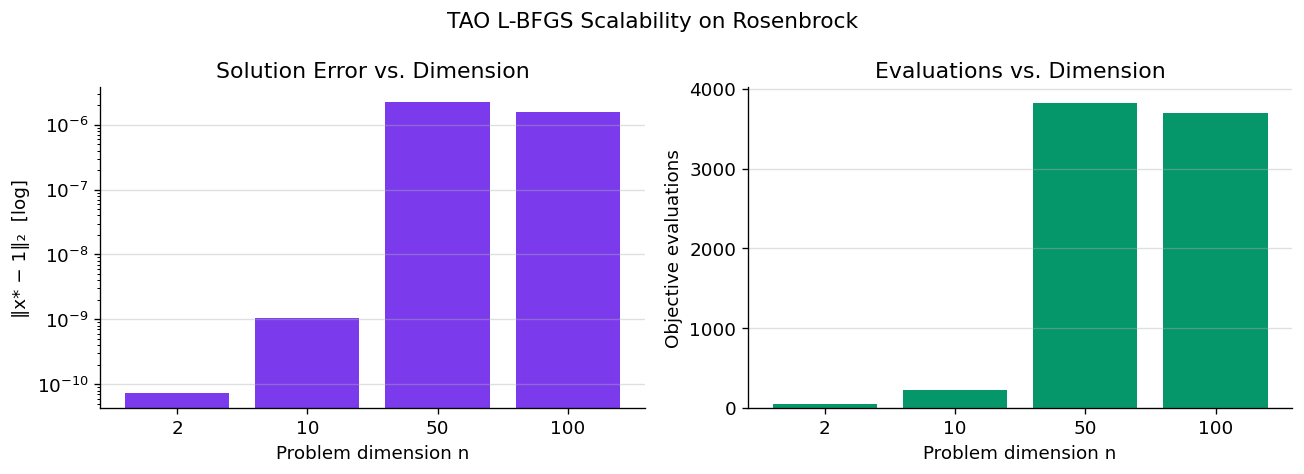

In [6]:
from petsc4py import PETSc

dims = [2, 10, 50, 100]
results = []

for n in dims:
    s = RosenbrockSolver(n=n)
    x_opt, fval = s.solve()
    err = np.linalg.norm(x_opt - 1.0)
    evals = len(s.obj_history)
    results.append({'n': n, 'fval': fval, 'err': err, 'evals': evals})
    print(f"n={n:4d}  f*={fval:.3e}  ||x*-1||={err:.3e}  evals={evals}")

# Summary bar chart
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ns    = [r['n']     for r in results]
errs  = [r['err']   for r in results]
evals = [r['evals'] for r in results]

axes[0].bar([str(n) for n in ns], errs, color='#7C3AED')
axes[0].set_yscale('log')
axes[0].set_xlabel('Problem dimension n')
axes[0].set_ylabel('‖x* − 1‖₂  [log]')
axes[0].set_title('Solution Error vs. Dimension')
axes[0].grid(axis='y', alpha=0.4)

axes[1].bar([str(n) for n in ns], evals, color='#059669')
axes[1].set_xlabel('Problem dimension n')
axes[1].set_ylabel('Objective evaluations')
axes[1].set_title('Evaluations vs. Dimension')
axes[1].grid(axis='y', alpha=0.4)

plt.suptitle('TAO L-BFGS Scalability on Rosenbrock', fontsize=13)
plt.tight_layout()
plt.show()

## 8. Solver Comparison — lmvm vs bncg

TAO provides several gradient-based solvers.  Here we compare L-BFGS (`lmvm`) against Nonlinear Conjugate Gradient (`bncg`) on the same n=10 problem.

  TAO type          : lmvm
  Converged reason  : 3
  Iterations        : 137
  Final f(x)        : 3.448307e-19
  TAO type          : bncg
  Converged reason  : 3
  Iterations        : 183
  Final f(x)        : 5.091885e-17


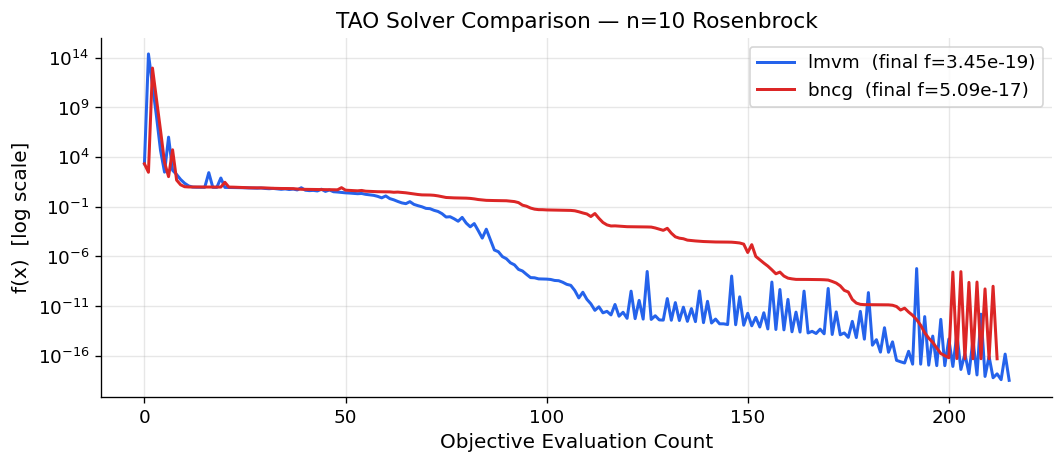

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))

colors = {'lmvm': '#2563EB', 'bncg': '#DC2626'}

for tao_type in ['lmvm', 'bncg']:
    s = RosenbrockSolver(n=10, tao_type=tao_type)
    x_opt, fval = s.solve()
    h = np.array(s.obj_history)
    ax.semilogy(h, linewidth=1.8, label=f'{tao_type}  (final f={fval:.2e})',
                color=colors[tao_type])

ax.set_xlabel('Objective Evaluation Count', fontsize=12)
ax.set_ylabel('f(x)  [log scale]', fontsize=12)
ax.set_title('TAO Solver Comparison — n=10 Rosenbrock', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Documented Functions — Quick Reference

The three functions documented in `docs/` are summarized below.  Full docstrings with source links are in the `docs/` directory.

---

### `Tao.setObjective(objective, args=None, kargs=None)`
Registers a Python callable that returns the scalar objective value $f(\mathbf{x})$.  
**C source:** `TaoSetObjective` in `src/tao/interface/taosolver.c`

```python
def my_obj(tao, x):              # signature required by TAO
    xa = x.getArray(readonly=True)
    return float(np.sum((xa - 1)**2))  # must return a float

tao.setObjective(my_obj)
```

---

### `Tao.setGradient(gradient, g, args=None, kargs=None)`
Registers a Python callable that writes $\nabla f(\mathbf{x})$ **in-place** into a pre-allocated PETSc vector `g`.  
**C source:** `TaoSetGradient` in `src/tao/interface/taosolver.c`

```python
def my_grad(tao, x, g):          # g is the pre-allocated output vector
    xa = x.getArray(readonly=True)
    g.setArray(2.0 * (xa - 1))   # write in-place — no return value

g = x.duplicate()                # same parallel layout as solution
tao.setGradient(my_grad, g)
```

---

### `Tao.getConvergedReason() → PETSc.TAO.ConvergedReason`
Returns the integer-enum reason the solver stopped. Positive = success; negative = failure.  
**C source:** `TaoGetConvergedReason` in `src/tao/interface/taosolver.c`

```python
tao.solve()
reason = tao.getConvergedReason()
print(reason, reason.name)       # e.g. 2  TAO_CONVERGED_GRTOL
assert reason > 0, f"TAO failed: {reason.name}"
```

## 10. Conclusion

This notebook demonstrated:

1. **Mathematical formulation** of the $n$-dimensional Rosenbrock problem, a standard optimization benchmark.
2. **PETSc TAO** (via `petsc4py`) as a high-performance solver for unconstrained minimization.
3. **L-BFGS** convergence from the classic starting point $(-1.2, 1.0, \ldots)$ to $\mathbf{x}^* \approx \mathbf{1}$ in tens of iterations, even in 100 dimensions.
4. Practical use of **three TAO API functions** (`setObjective`, `setGradient`, `getConvergedReason`) with full NumPy-style documentation in `docs/`.

The key engineering lesson: AI-translated code required careful debugging of callback signatures (`setGradient` writes in-place, not returns) and parameter names (`gatol`/`grtol` vs `rtol`/`atol`).  Reading the Cython source in `TAO.pyx` was essential to resolve these discrepancies.